In [5]:
import osmnx as ox
import geopandas as gpd
import contextily as cx

In [6]:
ibge = gpd.read_file("zip://Dados/BR_Municipios_2024.zip!BR_Municipios_2024.shp")

<Axes: >

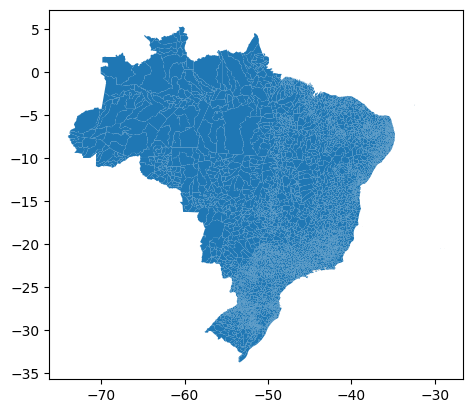

In [7]:
ibge.plot()

In [13]:
sp = ibge.loc[ibge["NM_MUN"]=="São Paulo"]
sp

,CD_MUN,NM_MUN,CD_RGI,NM_RGI,CD_RGINT,NM_RGINT,CD_UF,NM_UF,SIGLA_UF,CD_REGIA,NM_REGIA,SIGLA_RG,CD_CONCU,NM_CONCU,AREA_KM2,geometry
309,3550308,São Paulo,350001,São Paulo,3501,São Paulo,35,São Paulo,SP,3,Sudeste,SE,3550308,São Paulo/SP,1521.202,"POLYGON ((-46.61631 -23.87255, -46.61632 -23.8..."


<Axes: >

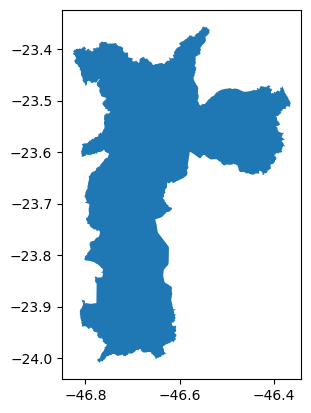

In [19]:
sp.plot()

In [11]:
tags = {"amenity": ['bar','biergarten','cafe','fast_food','food_court','ice_cream','pub','restaurant','bus_station'],
        "building": ['supermarket'],
        "public_transport": ['station'],
        "highway": ['bus_stop'],
        "shop": ['alcohol','bakery','beverages','brewing_supplies','butcher','cheese','chocolate','coffee','confectionery','convenience','dairy','deli','farm','food',
                 'department_store','general','kiosk','mall','supermarket','wholesale']} 
# (dict) – Dict of tags used for finding objects in the selected area: pois.

In [16]:
tags = {"public_transport": ['station']}

In [20]:
features = ox.features.features_from_polygon(sp.geometry.iloc[0], tags) 
print("Quantidade de pontos: {}".format(len(features)))
print(features.columns)
features.head(5)

Quantidade de pontos: 267
Index(['geometry', 'amenity', 'bus', 'name', 'public_transport', 'trolleybus',
       'operator', 'railway', 'ref', 'station',
       ...
       'building:material', 'building:min_level', 'access', 'fee', 'parking',
       'capacity', 'depot', 'industrial', 'landuse', 'logistics'],
      dtype='str', length=110)


geometry      amenity  bus  \
element id                                                          
node    438679064    POINT (-46.52273 -23.5584)  bus_station  yes   
        605663613    POINT (-46.69112 -23.5465)          NaN  NaN   
        656057672   POINT (-46.76746 -23.65959)  bus_station  yes   
        1094990809  POINT (-46.62211 -23.64887)  bus_station  yes   
        1707931136  POINT (-46.69026 -23.54709)  bus_station  yes   

                                                       name public_transport  \
element id                                                                     
node    438679064                      Terminal Vila Carrao          station   
        605663613                             Vila Madalena          station   
        656057672   Terminal Metropolitano de Capão Redondo          station   
        1094990809      Ponte Orca Zoo - Terminal Jabaquara          station   
        1707931136                   Terminal Vila Madalena          station   

                   trolleybus                    operator  railway  ref  \
element id                                                                
node    438679064         yes                         NaN      NaN  NaN   
        605663613         NaN  Metropolitano de São Paulo  station  VMD   
        656057672         NaN                         NaN      NaN  NaN   
        1094990809        NaN                         NaN      NaN  NaN   
        1707931136        NaN                         NaN      NaN  NaN   

                   station  ... building:material building:min_level access  \
element id                  ...                                               
node    438679064      NaN  ...               NaN                NaN    NaN   
        605663613   subway  ...               NaN                NaN    NaN   
        656057672      NaN  ...               NaN                NaN    NaN   
        1094990809     NaN  ...               NaN                NaN    NaN   
        1707931136     NaN  ...               NaN                NaN    NaN   

                    fee parking capacity depot industrial landuse logistics  
element id                                                                   
node    438679064   NaN     NaN      NaN   NaN        NaN     NaN       NaN  
        605663613   NaN     NaN      NaN   NaN        NaN     NaN       NaN  
        656057672   NaN     NaN      NaN   NaN        NaN     NaN       NaN  
        1094990809  NaN     NaN      NaN   NaN        NaN     NaN       NaN  
        1707931136  NaN     NaN      NaN   NaN        NaN     NaN       NaN  

[5 rows x 110 columns]

In [ ]:
features.value_counts("station", dropna=False)

station
subway    88
Name: count, dtype: int64

<Axes: >

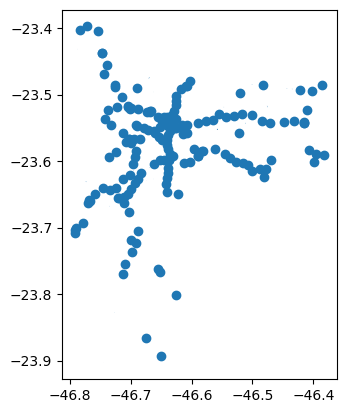

In [21]:
features.plot()

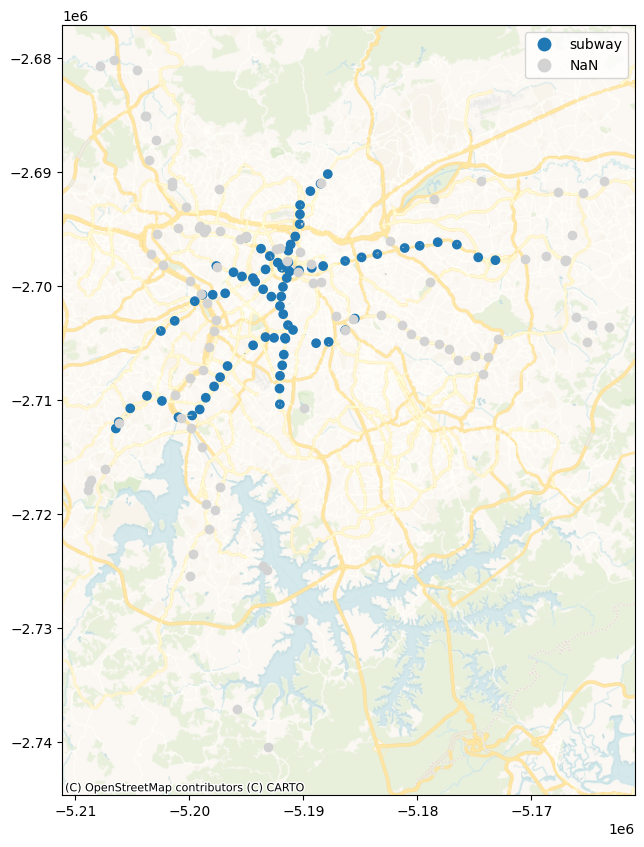

In [25]:
ax = features.to_crs(epsg=3857).plot(
    column='station', 
    categorical=True, 
    legend=True,
    figsize=(10, 10),
    cmap='tab20',
    missing_kwds={'color': 'lightgrey'}
)
cx.add_basemap(ax, source=cx.providers.CartoDB.VoyagerNoLabels)